In [1]:
# Block 1: Import libraries and setup
import fastf1
import pandas as pd
import numpy as np
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

# 设置 cache 路径
cache_path = './f1_cache'
fastf1.Cache.enable_cache(cache_path)

print("✅ Libraries imported")
print(f"✅ Cache enabled at: {cache_path}")

✅ Libraries imported
✅ Cache enabled at: ./f1_cache


In [2]:
# Block 2: Scan available races
import os

def scan_available_races(cache_path):
    """扫描本地 cache 中的所有比赛"""
    races = []
    
    for year_folder in ['2024', '2025']:
        year_path = Path(cache_path) / year_folder
        if not year_path.exists():
            continue
            
        for race_folder in sorted(year_path.iterdir()):
            if race_folder.is_dir() and 'Grand_Prix' in race_folder.name:
                # 解析比赛信息
                parts = race_folder.name.split('_')
                date = parts[0]
                race_name = ' '.join(parts[1:]).replace('_', ' ')
                
                # 检查是否有 Race 和 Qualifying 数据
                has_race = (race_folder / 'Race').exists() or any('Race' in f.name for f in race_folder.iterdir())
                has_quali = (race_folder / 'Qualifying').exists() or any('Qualifying' in f.name for f in race_folder.iterdir())
                
                races.append({
                    'Year': int(year_folder),
                    'Date': date,
                    'RaceName': race_name,
                    'FolderName': race_folder.name,
                    'HasRace': has_race,
                    'HasQualifying': has_quali
                })
    
    return pd.DataFrame(races)

# 扫描
available_races = scan_available_races(cache_path)
print(f"\n📊 Found {len(available_races)} races:")
print(available_races)

# 筛选有完整数据的比赛
complete_races = available_races[
    (available_races['HasRace'] == True) & 
    (available_races['HasQualifying'] == True)
]

print(f"\n✅ {len(complete_races)} races have both Race and Qualifying data")
print(complete_races[['Year', 'RaceName']])


📊 Found 46 races:
    Year        Date                   RaceName  \
0   2024  2024-03-02         Bahrain Grand Prix   
1   2024  2024-03-09   Saudi Arabian Grand Prix   
2   2024  2024-03-24      Australian Grand Prix   
3   2024  2024-04-07        Japanese Grand Prix   
4   2024  2024-04-21         Chinese Grand Prix   
5   2024  2024-05-05           Miami Grand Prix   
6   2024  2024-05-19  Emilia Romagna Grand Prix   
7   2024  2024-05-26          Monaco Grand Prix   
8   2024  2024-06-09        Canadian Grand Prix   
9   2024  2024-06-23         Spanish Grand Prix   
10  2024  2024-06-30        Austrian Grand Prix   
11  2024  2024-07-07         British Grand Prix   
12  2024  2024-07-21       Hungarian Grand Prix   
13  2024  2024-07-28         Belgian Grand Prix   
14  2024  2024-08-25           Dutch Grand Prix   
15  2024  2024-09-01         Italian Grand Prix   
16  2024  2024-09-15      Azerbaijan Grand Prix   
17  2024  2024-09-22       Singapore Grand Prix   
18  2024  20

In [3]:
# Block 3: Define data extraction functions

def load_race_session(year, race_name, session_type='R'):
    """
    加载比赛 session
    
    Parameters:
        year: 2024 or 2025
        race_name: 'Bahrain', 'Saudi Arabia', etc.
        session_type: 'R' for Race, 'Q' for Qualifying
    """
    try:
        session = fastf1.get_session(year, race_name, session_type)
        session.load()
        return session
    except Exception as e:
        print(f"❌ Error loading {year} {race_name} {session_type}: {e}")
        return None

def extract_race_results(session, year, race_name):
    """提取比赛结果"""
    if session is None:
        return None
    
    results = session.results.copy()
    
    # 提取关键信息
    race_data = pd.DataFrame({
        'Year': year,
        'RaceName': race_name,
        'DriverNumber': results['DriverNumber'],
        'DriverCode': results['Abbreviation'],
        'DriverName': results['FullName'],
        'Team': results['TeamName'],
        'GridPosition': results['GridPosition'],
        'Position': results['Position'],
        'Status': results['Status'],
        'Points': results['Points']
    })
    
    # 处理 DNF
    race_data['FinishPosition'] = race_data['Position'].fillna(20)
    race_data['DidFinish'] = race_data['Status'].str.contains('Finished', na=False)
    
    return race_data

def extract_qualifying_results(session):
    """提取排位赛结果"""
    if session is None:
        return None
    
    results = session.results.copy()
    
    quali_data = pd.DataFrame({
        'DriverNumber': results['DriverNumber'],
        'DriverCode': results['Abbreviation'],
        'QualifyingPosition': results['Position'],
        'Q1': results['Q1'],
        'Q2': results['Q2'],
        'Q3': results['Q3']
    })
    
    return quali_data

print("✅ Extraction functions defined")

✅ Extraction functions defined


In [ ]:
# Block 4: Extract all race data

all_race_data = []

# 定义2024年的比赛
races_2024 = [
    'Bahrain', 'Saudi Arabia', 'Australia', 'Japan', 'China',
    'Miami', 'Emilia Romagna', 'Monaco', 'Canada', 'Spain',
    'Austria', 'Great Britain', 'Hungary', 'Belgium', 'Netherlands',
    'Italy', 'Azerbaijan', 'Singapore', 'United States', 'Mexico',
    'Brazil', 'Las Vegas', 'Qatar', 'Abu Dhabi'
]

# 2025年已完成的比赛（根据你的 cache）
races_2025 = [
    'Australia', 'China', 'Japan', 'Bahrain', 'Saudi Arabia',
    'Miami', 'Emilia Romagna', 'Monaco', 'Spain', 'Canada',
    'Austria', 'Great Britain', 'Belgium', 'Hungary', 'Netherlands',
    'Italy', 'Azerbaijan', 'Singapore', 'United States', 'Mexico',
    'São Paulo', 'Las Vegas'
]

print("🔄 Starting data extraction...")
print("This may take 5-10 minutes...\n")

for year, races in [(2025, races_2025)]:
    print(f"\n{'='*50}")
    print(f"Processing {year} season")
    print('='*50)
    
    for i, race_name in enumerate(races, 1):
        print(f"[{i}/{len(races)}] {race_name}...", end=' ')
        
        try:
            # Load Race session
            race_session = load_race_session(year, race_name, 'R')
            if race_session is None:
                print("❌ No race data")
                continue
            
            # Load Qualifying session
            quali_session = load_race_session(year, race_name, 'Q')
            if quali_session is None:
                print("⚠️ No qualifying data")
                continue
            
            # Extract data
            race_df = extract_race_results(race_session, year, race_name)
            quali_df = extract_qualifying_results(quali_session)
            
            # Merge
            merged = race_df.merge(
                quali_df[['DriverNumber', 'QualifyingPosition']],
                on='DriverNumber',
                how='left'
            )
            
            all_race_data.append(merged)
            print(f"✅ {len(merged)} drivers")
            
        except Exception as e:
            print(f"❌ Error: {e}")
            continue

# Combine all data
if all_race_data:
    full_dataset = pd.concat(all_race_data, ignore_index=True)
    print(f"\n\n🎉 Data extraction complete!")
    print(f"Total records: {len(full_dataset)}")
    print(f"Races: {full_dataset['RaceName'].nunique()}")
    print(f"Drivers: {full_dataset['DriverCode'].nunique()}")
else:
    print("❌ No data extracted!")

In [12]:
# Block 5: Data quality check

print("="*60)
print("DATA QUALITY REPORT")
print("="*60)

print("\n1️⃣ Dataset Overview:")
print(f"   - Total records: {len(full_dataset)}")
print(f"   - Races: {full_dataset.groupby('Year')['RaceName'].nunique().to_dict()}")
print(f"   - Unique drivers: {full_dataset['DriverCode'].nunique()}")
print(f"   - Unique teams: {full_dataset['Team'].nunique()}")

print("\n2️⃣ Missing Data:")
missing = full_dataset.isnull().sum()
missing = missing[missing > 0]
if len(missing) > 0:
    print(missing)
else:
    print("   ✅ No missing values!")

print("\n3️⃣ Position Data Check:")
print(f"   - Position range: {full_dataset['Position'].min()} to {full_dataset['Position'].max()}")
print(f"   - Grid range: {full_dataset['GridPosition'].min()} to {full_dataset['GridPosition'].max()}")
print(f"   - Qualifying range: {full_dataset['QualifyingPosition'].min()} to {full_dataset['QualifyingPosition'].max()}")

print("\n4️⃣ Qualifying vs Grid Correlation:")
# 这是关键检查！
correlation = full_dataset[['QualifyingPosition', 'GridPosition']].corr().iloc[0, 1]
print(f"   Correlation: {correlation:.4f}")

if correlation > 0.99:
    print("   ⚠️ WARNING: Almost perfect correlation - might be copied data!")
elif correlation > 0.90:
    print("   ✅ Good: Strong correlation with some penalties")
else:
    print("   ⚠️ Check: Correlation seems low")

print("\n5️⃣ Sample Data:")
print(full_dataset.head(10))

print("\n6️⃣ DNF Statistics:")
dnf_rate = (~full_dataset['DidFinish']).mean()
print(f"   Overall DNF rate: {dnf_rate:.1%}")
print(f"   Total DNFs: {(~full_dataset['DidFinish']).sum()}")

DATA QUALITY REPORT

1️⃣ Dataset Overview:
   - Total records: 439
   - Races: {2025: 22}
   - Unique drivers: 21
   - Unique teams: 10

2️⃣ Missing Data:
QualifyingPosition    1
dtype: int64

3️⃣ Position Data Check:
   - Position range: 1.0 to 20.0
   - Grid range: 1.0 to 20.0
   - Qualifying range: 1.0 to 20.0

4️⃣ Qualifying vs Grid Correlation:
   Correlation: 0.9899
   ✅ Good: Strong correlation with some penalties

5️⃣ Sample Data:
   Year   RaceName DriverNumber DriverCode             DriverName  \
0  2025  Australia            4        NOR           Lando Norris   
1  2025  Australia            1        VER         Max Verstappen   
2  2025  Australia           63        RUS         George Russell   
3  2025  Australia           12        ANT  Andrea Kimi Antonelli   
4  2025  Australia           23        ALB        Alexander Albon   
5  2025  Australia           18        STR           Lance Stroll   
6  2025  Australia           27        HUL        Nico Hulkenberg   
7  20

In [13]:
# Block 6: Feature engineering

print("🔧 Creating model features...\n")

# 1. Create RaceID
full_dataset['RaceID'] = full_dataset.groupby(['Year', 'RaceName']).ngroup()

# 2. Team/Constructor mapping
team_mapping = {team: idx for idx, team in enumerate(full_dataset['Team'].unique())}
full_dataset['ConstructorIdx'] = full_dataset['Team'].map(team_mapping)

# 3. Driver mapping
driver_mapping = {driver: idx for idx, driver in enumerate(full_dataset['DriverCode'].unique())}
full_dataset['DriverIdx'] = full_dataset['DriverCode'].map(driver_mapping)

# 4. Constructor-Season index
full_dataset['ConstructorSeason'] = (
    full_dataset['Team'].astype(str) + '_' + 
    full_dataset['Year'].astype(str)
)
constructor_season_mapping = {cs: idx for idx, cs in 
                              enumerate(full_dataset['ConstructorSeason'].unique())}
full_dataset['ConstructorSeasonIdx'] = full_dataset['ConstructorSeason'].map(
    constructor_season_mapping
)

# 5. Track type (你需要手动定义，或者我帮你自动分类)
# 暂时先用简单的分类
track_types = {
    # High speed
    'Monza': 'high_speed', 'Spa': 'high_speed', 'Silverstone': 'high_speed',
    'Jeddah': 'high_speed',
    
    # Technical
    'Monaco': 'technical', 'Singapore': 'technical', 'Hungary': 'technical',
    'Zandvoort': 'technical',
    
    # Balanced (default)
}

def classify_track(race_name):
    for track, type_ in track_types.items():
        if track.lower() in race_name.lower():
            return type_
    return 'balanced'

full_dataset['TrackType'] = full_dataset['RaceName'].apply(classify_track)
track_type_mapping = {'high_speed': 0, 'balanced': 1, 'technical': 2}
full_dataset['TrackTypeIdx'] = full_dataset['TrackType'].map(track_type_mapping)

# 6. Recent form (rolling average of last 3 races)
full_dataset = full_dataset.sort_values(['DriverCode', 'Year', 'RaceID'])

full_dataset['Recent3Avg'] = full_dataset.groupby('DriverCode')['FinishPosition'].transform(
    lambda x: x.shift(1).rolling(window=3, min_periods=1).mean()
)

# 7. Cumulative DNF rate
full_dataset['CumulativeDNFs'] = full_dataset.groupby('DriverCode')['DidFinish'].transform(
    lambda x: (~x).shift(1).expanding().sum()
)
full_dataset['CumulativeRaces'] = full_dataset.groupby('DriverCode').cumcount()
full_dataset['CumDNFRate'] = (
    full_dataset['CumulativeDNFs'] / full_dataset['CumulativeRaces'].clip(lower=1)
).fillna(0)

# 8. Effective Position (for modeling - treat DNF as position 20)
full_dataset['EffectivePosition'] = full_dataset['FinishPosition'].fillna(20)

print("✅ Feature engineering complete!\n")

# Show summary
print("📊 Feature Summary:")
print(f"   - Constructors: {full_dataset['ConstructorIdx'].nunique()}")
print(f"   - Constructor-Seasons: {full_dataset['ConstructorSeasonIdx'].nunique()}")
print(f"   - Drivers: {full_dataset['DriverIdx'].nunique()}")
print(f"   - Track types: {full_dataset['TrackType'].value_counts().to_dict()}")

# Show sample
print("\n📋 Sample with features:")
display_cols = ['Year', 'RaceName', 'DriverCode', 'Team', 
                'QualifyingPosition', 'GridPosition', 'EffectivePosition',
                'Recent3Avg', 'CumDNFRate', 'TrackType']
print(full_dataset[display_cols].head(10))

🔧 Creating model features...

✅ Feature engineering complete!

📊 Feature Summary:
   - Constructors: 10
   - Constructor-Seasons: 10
   - Drivers: 21
   - Track types: {'balanced': 360, 'technical': 60, 'high_speed': 19}

📋 Sample with features:
     Year        RaceName DriverCode      Team  QualifyingPosition  \
4    2025       Australia        ALB  Williams                 6.0   
215  2025         Austria        ALB  Williams                12.0   
331  2025      Azerbaijan        ALB  Williams                19.0   
71   2025         Bahrain        ALB  Williams                15.0   
244  2025         Belgium        ALB  Williams                 5.0   
198  2025          Canada        ALB  Williams                10.0   
26   2025           China        ALB  Williams                10.0   
124  2025  Emilia Romagna        ALB  Williams                 7.0   
235  2025   Great Britain        ALB  Williams                12.0   
273  2025         Hungary        ALB  Williams        

In [14]:
# Block 8: Save cleaned data

# 保存完整数据集
output_file = 'f1_race_data_cleaned.csv'
full_dataset.to_csv(output_file, index=False)
print(f"✅ Saved to: {output_file}")

# 保存元数据（mapping dictionaries）
import json

metadata = {
    'n_races': int(full_dataset['RaceID'].nunique()),
    'n_drivers': int(full_dataset['DriverIdx'].nunique()),
    'n_constructors': int(full_dataset['ConstructorIdx'].nunique()),
    'n_constructor_seasons': int(full_dataset['ConstructorSeasonIdx'].nunique()),
    'driver_mapping': driver_mapping,
    'constructor_mapping': team_mapping,
    'constructor_season_mapping': constructor_season_mapping,
    'track_type_mapping': track_type_mapping
}

with open('f1_metadata.json', 'w') as f:
    json.dump(metadata, f, indent=2)

print(f"✅ Saved metadata to: f1_metadata.json")

print("\n" + "="*60)
print("DATA PREPARATION COMPLETE!")
print("="*60)
print(f"\nYou now have:")
print(f"  1. {output_file} - Clean race data ready for PyMC")
print(f"  2. f1_metadata.json - Mappings and counts")
print(f"\nNext step: Build the PyMC model!")

✅ Saved to: f1_race_data_cleaned.csv
✅ Saved metadata to: f1_metadata.json

DATA PREPARATION COMPLETE!

You now have:
  1. f1_race_data_cleaned.csv - Clean race data ready for PyMC
  2. f1_metadata.json - Mappings and counts

Next step: Build the PyMC model!


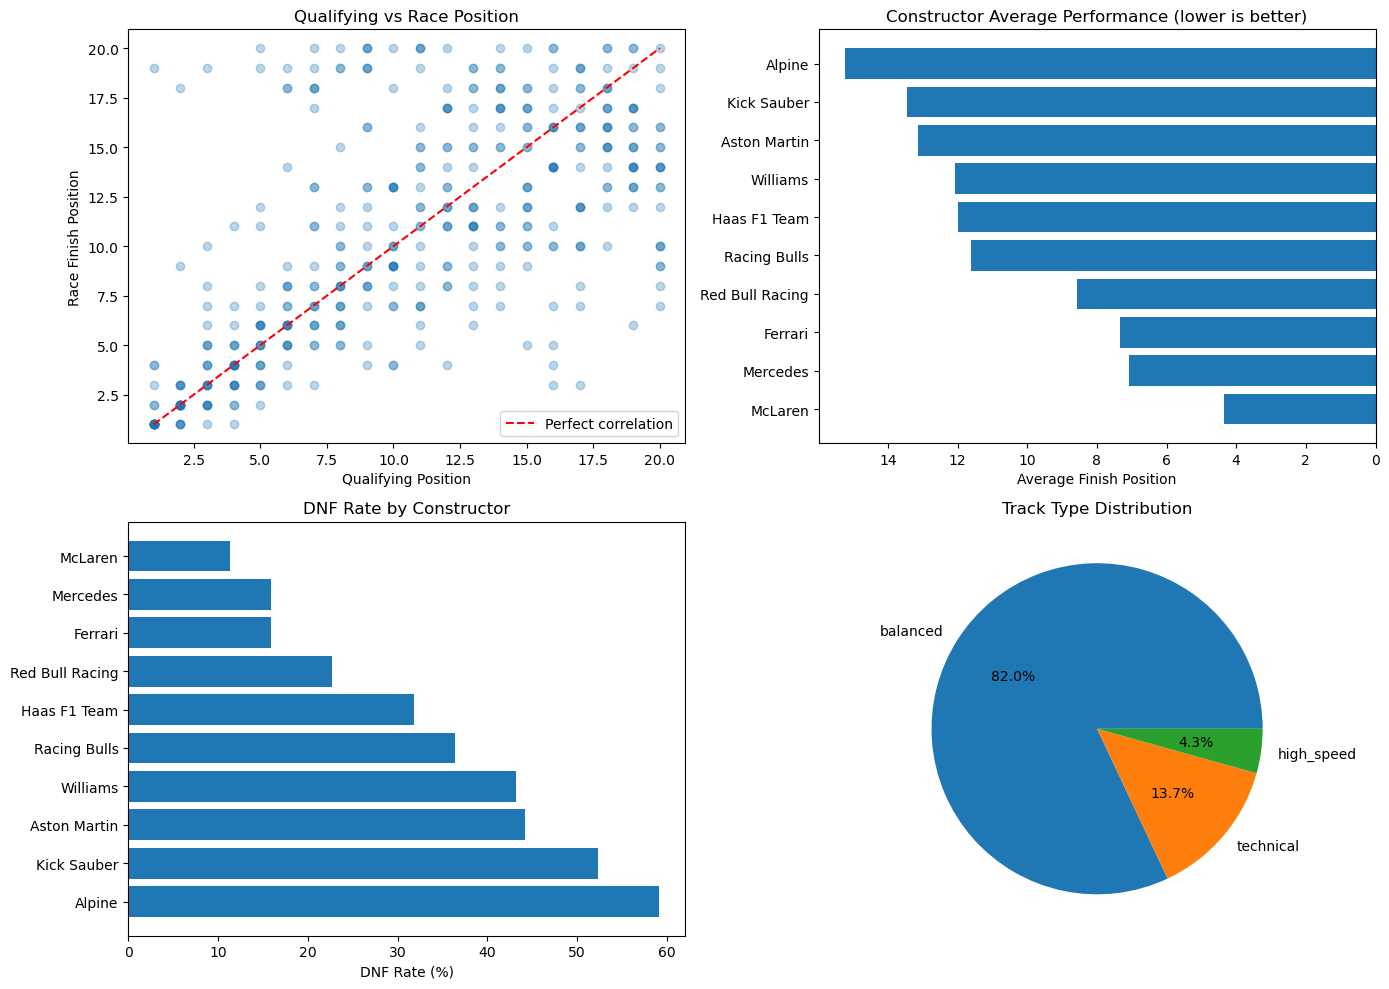

✅ Visualization saved as: f1_data_exploration.png


In [15]:
# Block 9: Quick visualizations

import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Qualifying vs Race position
axes[0, 0].scatter(full_dataset['QualifyingPosition'], 
                   full_dataset['EffectivePosition'],
                   alpha=0.3)
axes[0, 0].plot([1, 20], [1, 20], 'r--', label='Perfect correlation')
axes[0, 0].set_xlabel('Qualifying Position')
axes[0, 0].set_ylabel('Race Finish Position')
axes[0, 0].set_title('Qualifying vs Race Position')
axes[0, 0].legend()

# 2. Constructor performance
constructor_avg = full_dataset.groupby('Team')['EffectivePosition'].mean().sort_values()
axes[0, 1].barh(constructor_avg.index, constructor_avg.values)
axes[0, 1].set_xlabel('Average Finish Position')
axes[0, 1].set_title('Constructor Average Performance (lower is better)')
axes[0, 1].invert_xaxis()

# 3. DNF rates by constructor
dnf_by_team = full_dataset.groupby('Team')['DidFinish'].apply(lambda x: (~x).mean()).sort_values(ascending=False)
axes[1, 0].barh(dnf_by_team.index, dnf_by_team.values * 100)
axes[1, 0].set_xlabel('DNF Rate (%)')
axes[1, 0].set_title('DNF Rate by Constructor')

# 4. Track type distribution
track_type_counts = full_dataset['TrackType'].value_counts()
axes[1, 1].pie(track_type_counts.values, labels=track_type_counts.index, autopct='%1.1f%%')
axes[1, 1].set_title('Track Type Distribution')

plt.tight_layout()
plt.savefig('f1_data_exploration.png', dpi=150, bbox_inches='tight')
plt.show()

print("✅ Visualization saved as: f1_data_exploration.png")